# 07c — embryo NMP subclustering

**Feeds:** Fig 4d, 4e (via stage 12)

**Position in the chain:** parity lineage. Supplies the embryo NMP label.

Ported from the original analysis. Saved cell outputs are from the original run, and paths in them appear as `<analysis-root>/...`.

This notebook ran on the earlier human embryo clustering object (`parity/results/intermediates/07_human_embryo/adata_embryo_with_clusters.h5ad`), and the SMD z-scores shipped for it come from that run, so it does not run on the embryo object `07_human_embryo.ipynb` builds here. The earlier object is in the Zenodo deposit (`../../data/DOWNLOAD.md`); `scrnaseq/run_chain.py` runs this notebook when it is present under `SCRNASEQ_INPUT_ROOT`, and skips it otherwise.

**Changes from the original notebook**, so that it runs from this repository:
1. Paths. The first code cell finds the repository from any working directory inside it; the original looked for `src/` at most two levels up, in the `parity` analysis directory. `PROJECT_ROOT` is `scrnaseq/chain_inputs/`, the shipped files that no notebook writes, laid out as the original analysis directory. The notebook reads and writes under `DEV_ROOT`, `$SCRNASEQ_RESULTS_ROOT/parity/` (default `scrnaseq/output/parity/`), instead of the `parity` directory itself.
2. The SMD z-scores for the embryo NMP subset are read from `scrnaseq/chain_inputs/parity/results/intermediates/07c_human_embryo_nmp_subclustering/` instead of the stage's output directory.

3. The embryo clusters object. `SCRNASEQ_INPUT_ROOT` (default `data/scrnaseq_inputs/`) is checked for `earlier_embryo_run/results/intermediates/07_human_embryo/adata_embryo_with_clusters.h5ad`; when absent, the notebook falls back to `embryo_stage_path`, as before this override existed (in practice unreachable, since `run_chain.py` only runs this notebook when the object is present).

No other line of code was changed.


# 07c Human Embryo NMP Subclustering

Downstream of stage `07_human_embryo` and the `07c` triage notebook. This notebook prepares the embryo NMP parent cluster for SMD, loads returned SMD z-scores, and builds a first NMP-oriented clustering workflow with the same downstream views we used in `07b`.

Note: this stage is currently parity-only and should be upgraded into trunk_main_dev in a future pass.


In [ ]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "trunk_morph_ref").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the repository root containing src/trunk_morph_ref/")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.trunk_morph_ref.paths import chain_inputs_root, scrnaseq_input_root

# Inputs that no notebook writes: scrnaseq/chain_inputs/, laid out as the original analysis directory.
PROJECT_ROOT = chain_inputs_root(REPO_ROOT)
# The earlier human embryo clusters object, fetched from the Zenodo deposit (see data/DOWNLOAD.md).
SCRNASEQ_INPUT_ROOT = scrnaseq_input_root(REPO_ROOT)

import os
os.chdir(REPO_ROOT)


In [ ]:

import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import seaborn as sns
from cmcrameri.cm import batlow
from scipy.sparse import save_npz


/opt/anaconda3/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version


/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3

In [ ]:

plt.rcParams["svg.fonttype"] = "none"  # Keep fonts editable in Illustrator

from src.trunk_morph_ref.cell_ordering import ordered_cells_by_cluster_clustermap
from src.trunk_morph_ref.correlation import (
    gene_corrcoef_dense_legacy as gene_corrcoef_sparse_safe,
)
from src.trunk_morph_ref.paths import init_output_paths, scrnaseq_results_root
from src.trunk_morph_ref.pipeline_io import load_h5ad, save_h5ad, save_json, stage_dir
from src.trunk_morph_ref.preprocessing import (
    assert_gene_id_index,
    ensure_gene_id_index,
    filter_genes_dense_legacy as filter_genes,
    install_scanpy_symbol_defaults,
    normalize_unit_variance_dense_legacy as normalize_unit_variance,
    resolve_symbols,
    var_names_to_symbols,
)

# Outputs: $SCRNASEQ_RESULTS_ROOT (default scrnaseq/output/), under parity/ as in the original.
DEV_ROOT = scrnaseq_results_root(REPO_ROOT) / "parity"
RESULTS_DIR, MANUSCRIPT_FIG_DIR, EXTENDED_FIG_DIR = init_output_paths(DEV_ROOT)
install_scanpy_symbol_defaults(sc)


In [ ]:

STAGE_ID = "07c_human_embryo_nmp_subclustering"
stage_path = stage_dir(RESULTS_DIR, STAGE_ID)
fig_path = stage_path / "figures"
table_path = stage_path / "tables"
stage_path.mkdir(parents=True, exist_ok=True)
fig_path.mkdir(parents=True, exist_ok=True)
table_path.mkdir(parents=True, exist_ok=True)

embryo_stage_path = stage_dir(RESULTS_DIR, "07_human_embryo")

# This notebook ran on the earlier human embryo clustering object; nothing in this chain writes
# it to embryo_stage_path (the parity lineage is not rebuilt here). Read it from the Zenodo
# deposit when present, otherwise fall back to embryo_stage_path, as before this override existed.
_earlier_embryo_clusters_path = (
    SCRNASEQ_INPUT_ROOT
    / "earlier_embryo_run/results/intermediates/07_human_embryo/adata_embryo_with_clusters.h5ad"
)
if _earlier_embryo_clusters_path.exists():
    adata_embryo_with_clusters = load_h5ad(_earlier_embryo_clusters_path)
else:
    adata_embryo_with_clusters = load_h5ad(embryo_stage_path / "adata_embryo_with_clusters.h5ad")
ensure_gene_id_index(adata_embryo_with_clusters)
assert_gene_id_index(adata_embryo_with_clusters)

print("Loaded upstream embryo artifact:")
print(embryo_stage_path / "adata_embryo_with_clusters.h5ad")
print(adata_embryo_with_clusters)


Loaded upstream embryo artifact:
<analysis-root>/parity/results/intermediates/07_human_embryo/adata_embryo_with_clusters.h5ad
AnnData object with n_obs × n_vars = 46768 × 26565
    obs: 'week_stage', 'source', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'leiden_embryo'
    var: 'gene_ids', 'feature_types-1-0-0-0-0-0-0-0-0-0-0-0', 'feature_types-1-0-0-0-0-0-0-0', 'feature_types-1-0-0-0-0-0', 'gene_symbol_original', 'gene_symbol', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'


## Provenance Note

In [ ]:
NMP_CORE_MARKERS = ["TBXT", "WNT3A", "NRP2"]
NMP_SUPPORTIVE_MARKERS = ["IL17RD", "SPRY4"]
AXIAL_COUNTER_MARKERS = ["DAND5", "CFC1", "NOTO", "TFF3", "MNX1", "APOA2"]
POSTERIOR_CONTEXT_MARKERS = ["THY1", "LCN15"]
NMP_DISPLAY_MARKERS = NMP_CORE_MARKERS + NMP_SUPPORTIVE_MARKERS + AXIAL_COUNTER_MARKERS + POSTERIOR_CONTEXT_MARKERS


def expr_vector_by_symbol(adata, symbol):
    gene_ids = resolve_symbols(adata, [symbol], strict=False, allow_missing=True)
    if not gene_ids:
        return None
    x = adata[:, gene_ids[0]].X
    if hasattr(x, "toarray"):
        x = x.toarray()
    return np.asarray(x).reshape(-1)


def cluster_marker_summary(adata_expr, cluster_key, marker_symbols, marker_cache=None):
    if marker_cache is None:
        marker_cache = {symbol: expr_vector_by_symbol(adata_expr, symbol) for symbol in marker_symbols}
    rows = []
    for cluster in adata_expr.obs[cluster_key].cat.categories:
        mask = (adata_expr.obs[cluster_key] == cluster).values
        row = {"cluster": cluster, "n_cells": int(mask.sum())}
        for symbol in marker_symbols:
            values = marker_cache.get(symbol)
            if values is None:
                row[f"{symbol}_mean"] = np.nan
                row[f"{symbol}_pct_gt1"] = np.nan
            else:
                row[f"{symbol}_mean"] = float(values[mask].mean())
                row[f"{symbol}_pct_gt1"] = float((values[mask] > 1).mean())
        rows.append(row)
    return pd.DataFrame(rows)


def score_sum(marker_summary_df, markers):
    cols = [f"{g}_mean" for g in markers]
    if not cols:
        return pd.Series(0.0, index=marker_summary_df.index)
    return marker_summary_df[cols].fillna(0).sum(axis=1)


def nmp_score(marker_summary_df):
    return (
        2.0 * marker_summary_df[["TBXT_mean", "WNT3A_mean"]].fillna(0).sum(axis=1)
        + marker_summary_df[["NRP2_mean"]].fillna(0).sum(axis=1)
        + 0.5 * marker_summary_df[["IL17RD_mean", "SPRY4_mean"]].fillna(0).sum(axis=1)
        - marker_summary_df[["DAND5_mean", "CFC1_mean", "NOTO_mean", "TFF3_mean", "MNX1_mean", "APOA2_mean"]].fillna(0).sum(axis=1)
    )


def il17rd_high_score(marker_summary_df):
    return (
        2.0 * marker_summary_df[["IL17RD_mean"]].fillna(0).sum(axis=1)
        + marker_summary_df[["SPRY4_mean"]].fillna(0).sum(axis=1)
        + 0.5 * marker_summary_df[["TBXT_mean", "WNT3A_mean", "NRP2_mean"]].fillna(0).sum(axis=1)
        - marker_summary_df[["DAND5_mean", "CFC1_mean", "NOTO_mean", "TFF3_mean", "MNX1_mean", "APOA2_mean"]].fillna(0).sum(axis=1)
    )


def posterior_neural_score(marker_summary_df):
    return (
        marker_summary_df[["THY1_mean", "LCN15_mean"]].fillna(0).sum(axis=1)
        + 0.5 * marker_summary_df[["NRP2_mean"]].fillna(0).sum(axis=1)
        - 0.5 * marker_summary_df[["TBXT_mean", "WNT3A_mean"]].fillna(0).sum(axis=1)
        - marker_summary_df[["DAND5_mean", "CFC1_mean", "NOTO_mean", "TFF3_mean", "MNX1_mean", "APOA2_mean"]].fillna(0).sum(axis=1)
    )


def axial_score(marker_summary_df):
    return (
        marker_summary_df[["DAND5_mean", "CFC1_mean", "NOTO_mean", "TFF3_mean", "MNX1_mean", "APOA2_mean"]].fillna(0).sum(axis=1)
        + 0.5 * marker_summary_df[["TBXT_mean"]].fillna(0).sum(axis=1)
        - marker_summary_df[["WNT3A_mean", "NRP2_mean"]].fillna(0).sum(axis=1)
    )


## Select Parent Cluster

In [ ]:
nmp_parent_clusters = ['Week 3 Posterior Neural Tube / Neuromesodermal Progenitors']

adata_embryo_nmp = adata_embryo_with_clusters[
    adata_embryo_with_clusters.obs["leiden_embryo"].isin(nmp_parent_clusters).values,
    :,
].copy()

print(f"Selected {adata_embryo_nmp.n_obs} NMP parent-cluster cells")
print(adata_embryo_nmp.obs["leiden_embryo"].astype(str).value_counts())


Selected 635 NMP parent-cluster cells
leiden_embryo
Week 3 Posterior Neural Tube / Neuromesodermal Progenitors    635
Name: count, dtype: int64


## Fresh Subset Preprocessing For SMD

In [ ]:
adata_embryo_nmp_filtered = filter_genes(
    adata_embryo_nmp,
    mean_cutoff=0.05,
    std_cutoff=0.05,
)
adata_embryo_nmp_filtered = normalize_unit_variance(adata_embryo_nmp_filtered)

counts = adata_embryo_nmp_filtered.X
cv_mask = np.mean(counts, axis=0).transpose() < 1
adata_embryo_nmp_filtered = adata_embryo_nmp_filtered[:, cv_mask]

print(
    str(adata_embryo_nmp_filtered.n_obs)
    + " cells after NMP subset preprocessing\n"
    + str(adata_embryo_nmp_filtered.n_vars)
    + " genes after preprocessing\nRecommended n_sub ≈ "
    + str(int(0.8 * adata_embryo_nmp_filtered.n_obs))
)


14248 genes after filtering


635 cells after NMP subset preprocessing
13013 genes after preprocessing
Recommended n_sub ≈ 508


In [ ]:
adata_embryo_nmp_ = filter_genes(adata_embryo_nmp.copy(), mean_cutoff=0, std_cutoff=0)
adata_embryo_nmp_ = normalize_unit_variance(adata_embryo_nmp_)

for _adata in [adata_embryo_with_clusters, adata_embryo_nmp_filtered, adata_embryo_nmp_]:
    assert_gene_id_index(_adata)


17019 genes after filtering


## Save SMD Prep Outputs

In [ ]:
save_npz(stage_path / "embryo_nmp_07c.npz", adata_embryo_nmp_filtered.X)
save_h5ad(adata_embryo_nmp_filtered, stage_path / "adata_embryo_nmp_filtered.h5ad")
save_h5ad(adata_embryo_nmp_, stage_path / "adata_embryo_nmp_.h5ad")
adata_embryo_nmp_.obs[["leiden_embryo"]].to_csv(stage_path / "nmp_parent_cluster_labels.csv")

save_json(
    {
        "stage": STAGE_ID,
        "seed_policy": "all seeds set to 0",
        "upstream_stage": "07_human_embryo",
        "upstream_identification_stage": "07c_human_embryo_nmp_identification",
        "parent_clusters": nmp_parent_clusters,
        "preferred_fresh_smd_substrate": "embryo_nmp",
        "n_parent_cluster_cells": int(adata_embryo_nmp_.n_obs),
        "n_pre_smd_genes": int(adata_embryo_nmp_filtered.n_vars),
        "n_postfilter_genes": int(adata_embryo_nmp_.n_vars),
        "recommended_n_sub": int(0.8 * adata_embryo_nmp_filtered.n_obs),
        "smd_input_matrix": "embryo_nmp_07c.npz",
        "filtered_artifact": "adata_embryo_nmp_filtered.h5ad",
        "downstream_artifact": "adata_embryo_nmp_.h5ad",
    },
    stage_path / "meta.json",
)

print(f"Saved NMP SMD prep outputs to {stage_path}")


/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1190: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1190: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


Saved NMP SMD prep outputs to <analysis-root>/parity/results/intermediates/07c_human_embryo_nmp_subclustering


## Load Returned NMP SMD Z-Scores

In [ ]:

z_score_file = PROJECT_ROOT / "parity" / "results" / "intermediates" / STAGE_ID / "z_embryo_nmp_07c_001.npy"
z_scores_embryo_nmp = np.load(z_score_file)
if len(z_scores_embryo_nmp) != adata_embryo_nmp_filtered.n_vars:
    raise ValueError(
        f"{z_score_file.name} length ({len(z_scores_embryo_nmp)}) does not match "
        f"filtered NMP gene count ({adata_embryo_nmp_filtered.n_vars})."
    )

adata_embryo_nmp_filtered.var["z_score_embryo_nmp"] = z_scores_embryo_nmp
adata_embryo_nmp_filtered.var["log1p_z_score_embryo_nmp"] = np.log1p(z_scores_embryo_nmp)
adata_embryo_nmp_.var["z_score_embryo_nmp"] = np.nan
for gene_id in adata_embryo_nmp_filtered.var_names:
    adata_embryo_nmp_.var.loc[gene_id, "z_score_embryo_nmp"] = adata_embryo_nmp_filtered.var.loc[
        gene_id, "z_score_embryo_nmp"
    ]

print(f"Loaded {z_score_file.name} with {len(z_scores_embryo_nmp)} NMP z-scores")


Loaded z_embryo_nmp_07c_001.npy with 13013 NMP z-scores


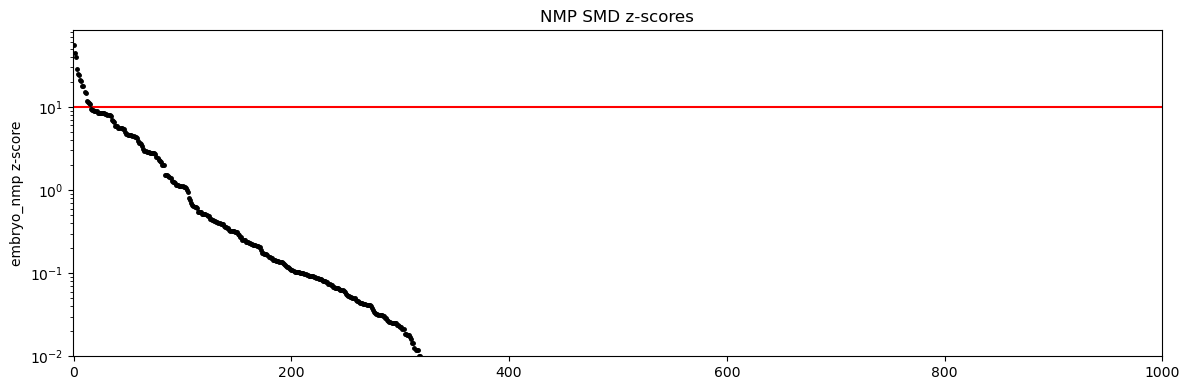

16 NMP genes with z_score >= cutoff


In [ ]:
smd_cutoff = 10

plt.figure(figsize=(12, 4))
plt.hlines(smd_cutoff, -1, 2000, "r")
plt.plot(sorted(z_scores_embryo_nmp)[::-1], "k.", markersize=5)
plt.yscale("log")
plt.ylim(0.01, 1.5 * z_scores_embryo_nmp.max())
plt.xlim(-1, min(1000, len(z_scores_embryo_nmp)))
plt.ylabel("embryo_nmp z-score")
plt.title("NMP SMD z-scores")
plt.tight_layout()
plt.savefig(fig_path / "nmp_smd_z_scores.png", dpi=300, bbox_inches="tight")
plt.savefig(fig_path / "nmp_smd_z_scores.pdf", bbox_inches="tight")
plt.show()
print(f"{(z_scores_embryo_nmp > smd_cutoff).sum()} NMP genes with z_score >= cutoff")


## Select NMP SMD Genes

In [ ]:
genes_cellcycle = [
    "MKI67", "CENPE", "SGO2", "KIF14", "PIF1", "NDC80", "CDCA8", "PLK1", "AURKA", "UBE2C",
    "ASPM", "TOP2A", "TPX2", "NUSAP1", "CDC20", "CKS2", "KPNA2", "TUBB4B", "DLGAP5", "BIRC5",
    "HMMR", "CCNB1", "ARL6IP1", "PTTG1", "UBE2S", "DUT", "HELLS", "CLSPN", "RRM2", "PCLAF",
    "TYMS", "KIF18B", "SMC4", "HIST1H4C", "DIAPH3", "RFC3", "MIR924HG", "MIS18BP1", "TUBA1C", "CDK1",
    "CENPA", "KIF11", "ECT2", "KNL1", "NEK2", "CEP55", "PSRC1", "CDCA3", "CCNA2", "GTSE1",
    "CENPF", "CKS1B", "MELK", "CDCA5", "MCM4", "HIST1H1E", "BRCA2", "TRIM66", "C1orf112", "POLD3",
    "KIF23", "CDKAL1", "RAD51AP1", "RANBP1", "CDCA2", "CAND2", "EIF5A", "SRSF2", "GINS1", "GINS2",
]

manual_addgenes = [
    "TBXT", "FGF17", "GMPR", "HES7", "WNT5B",
]
manual_removegenes = []

cellcycle_gene_ids = set(resolve_symbols(adata_embryo_nmp_, genes_cellcycle, strict=False, allow_missing=True))
selected_by_z_cutoff = set(
    adata_embryo_nmp_filtered.var_names[
        adata_embryo_nmp_filtered.var.z_score_embryo_nmp > smd_cutoff
    ]
)
SMDembryo_nmpgenes = list(selected_by_z_cutoff)
for gene_symbol in manual_addgenes:
    for gene_id in resolve_symbols(adata_embryo_nmp_, [gene_symbol], strict=False, allow_missing=True):
        if gene_id not in SMDembryo_nmpgenes:
            SMDembryo_nmpgenes.append(gene_id)
for gene_symbol in manual_removegenes:
    for gene_id in resolve_symbols(adata_embryo_nmp_, [gene_symbol], strict=False, allow_missing=True):
        if gene_id in SMDembryo_nmpgenes:
            SMDembryo_nmpgenes.remove(gene_id)
SMDembryo_nmpgenes = [g for g in SMDembryo_nmpgenes if g not in cellcycle_gene_ids]
manual_add_gene_ids = set(resolve_symbols(adata_embryo_nmp_, manual_addgenes, strict=False, allow_missing=True))

adata_embryo_nmp_SMD = adata_embryo_nmp_[:, SMDembryo_nmpgenes].copy()
print(f"{adata_embryo_nmp_SMD.n_vars} NMP genes selected before correlation refinement")

19 NMP genes selected before correlation refinement


In [ ]:
corr_embryo_nmp_gg = gene_corrcoef_sparse_safe(adata_embryo_nmp_SMD.X)
keep_gene_ids = []
for i in range(corr_embryo_nmp_gg.shape[0]):
    off_diag = np.delete(corr_embryo_nmp_gg[i], i)
    l2_corr = np.sqrt(np.sum(np.square(off_diag)) / np.size(off_diag))
    if l2_corr > 0.06:
        keep_gene_ids.append(adata_embryo_nmp_SMD.var_names[i])

for gene_id in resolve_symbols(adata_embryo_nmp_, manual_addgenes, strict=False, allow_missing=True):
    if gene_id not in keep_gene_ids:
        keep_gene_ids.append(gene_id)
keep_gene_ids = [g for g in list(dict.fromkeys(keep_gene_ids)) if g not in cellcycle_gene_ids]

adata_embryo_nmp_SMD = adata_embryo_nmp_[:, keep_gene_ids].copy()
selected_smd_gene_table = pd.DataFrame(
    {
        "gene_id": adata_embryo_nmp_SMD.var_names,
        "gene_symbol": adata_embryo_nmp_SMD.var["gene_symbol"].astype(str).values,
        "z_score_embryo_nmp": adata_embryo_nmp_SMD.var["z_score_embryo_nmp"].astype(float).values,
        "selected_by_z_cutoff": [gene_id in selected_by_z_cutoff for gene_id in adata_embryo_nmp_SMD.var_names],
        "selected_manual_add": [gene_id in manual_add_gene_ids for gene_id in adata_embryo_nmp_SMD.var_names],
    }
).sort_values(["selected_manual_add", "z_score_embryo_nmp", "gene_symbol"], ascending=[False, False, True])
selected_smd_gene_table.to_csv(table_path / "nmp_selected_smd_genes.csv", index=False)
print(f"{adata_embryo_nmp_SMD.n_vars} NMP genes retained after correlation refinement")
selected_smd_gene_table


17 NMP genes retained after correlation refinement


            gene_id gene_symbol  z_score_embryo_nmp  selected_by_z_cutoff  \
14  ENSG00000137198        GMPR            0.214843                 False   
12  ENSG00000164458        TBXT            0.023942                 False   
13  ENSG00000158815       FGF17                 NaN                 False   
15  ENSG00000179111        HES7                 NaN                 False   
16  ENSG00000111186       WNT5B                 NaN                 False   
0   ENSG00000158874       APOA2           44.053573                  True   
7   ENSG00000177984       LCN15           40.308438                  True   
3   ENSG00000154096        THY1           25.124849                  True   
11  ENSG00000132026       RTBDN           21.098569                  True   
5   ENSG00000267457  AC004223.2           20.799201                  True   
6   ENSG00000237485   SGOL1-AS1           18.135261                  True   
1   ENSG00000081248     CACNA1S           18.032869                  True   

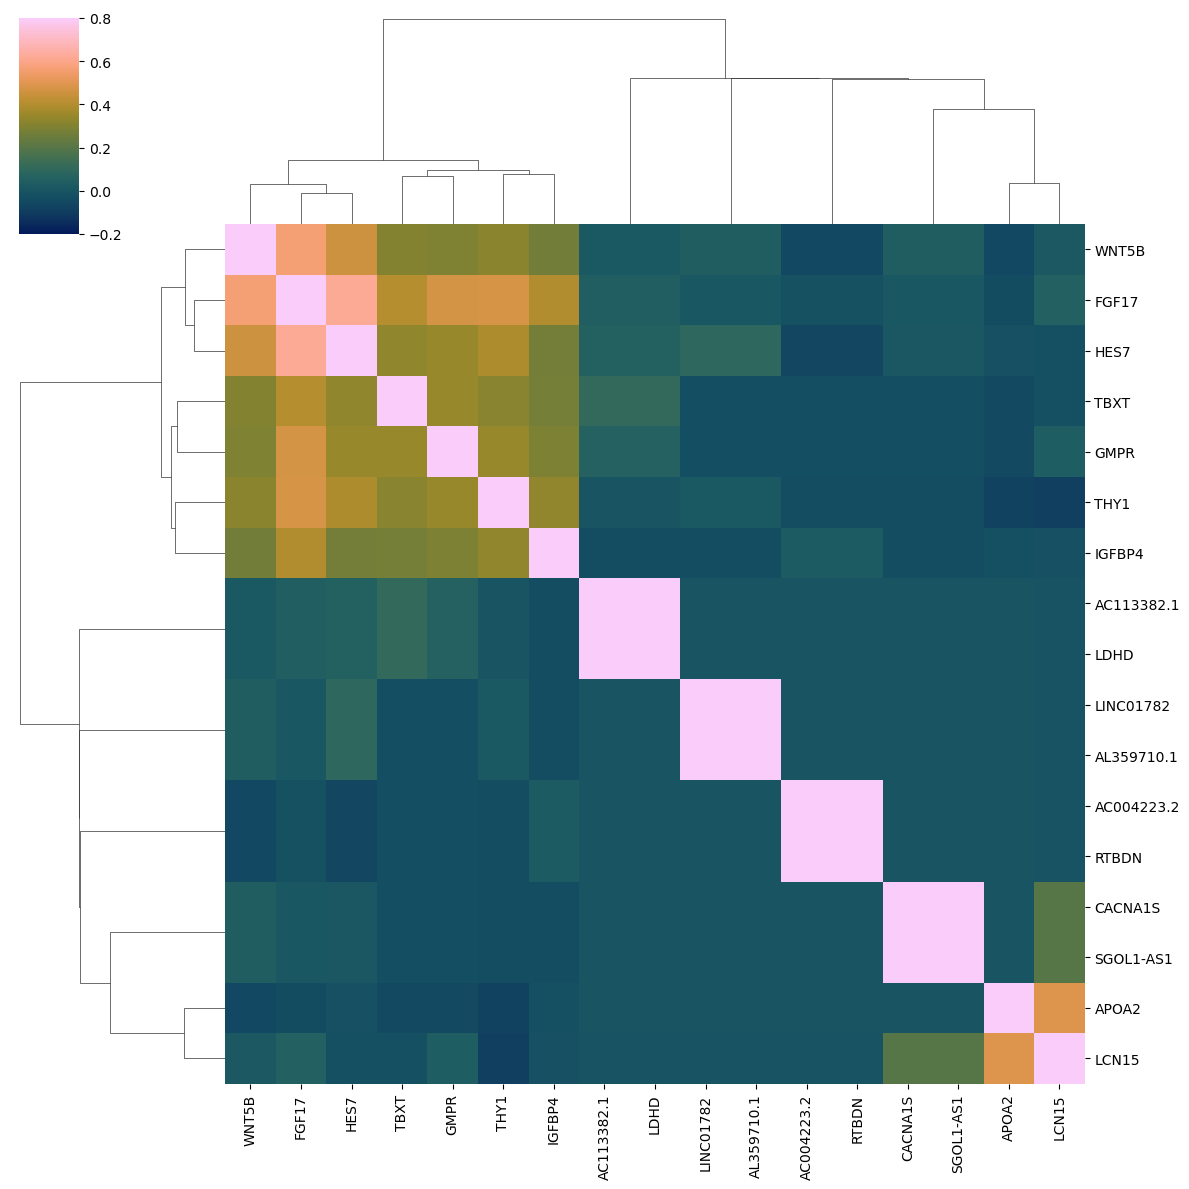

In [ ]:

corr_embryo_nmp_gg = gene_corrcoef_sparse_safe(adata_embryo_nmp_SMD.X)
cluster_gg_embryo_nmp = sns.clustermap(
    corr_embryo_nmp_gg,
    method="ward",
    metric="euclidean",
    figsize=(12, 12),
    cmap=batlow,
    vmin=-0.2,
    vmax=0.8,
    yticklabels=var_names_to_symbols(adata_embryo_nmp_SMD),
    xticklabels=var_names_to_symbols(adata_embryo_nmp_SMD),
)
cluster_gg_embryo_nmp.savefig(fig_path / "nmp_smd_gene_gene_correlation.png", dpi=300)
cluster_gg_embryo_nmp.savefig(fig_path / "nmp_smd_gene_gene_correlation.pdf")
plt.show()


## Screen a Small Leiden Resolution Ladder

In [ ]:
scan_resolutions = [0.08, 0.10, 0.15, 0.20, 0.24, 0.30, 0.40]
resolution_scan_rows = []
scan_marker_symbols = NMP_DISPLAY_MARKERS
scan_marker_cache = {symbol: expr_vector_by_symbol(adata_embryo_nmp_, symbol) for symbol in scan_marker_symbols}

adata_embryo_nmp_SMD_scan = adata_embryo_nmp_SMD.copy()
sc.pp.normalize_total(adata_embryo_nmp_SMD_scan)
sc.pp.neighbors(adata_embryo_nmp_SMD_scan, use_rep="X")

for resolution in scan_resolutions:
    adata_scan = adata_embryo_nmp_SMD_scan.copy()
    sc.tl.leiden(
        adata_scan,
        resolution=resolution,
        random_state=0,
        key_added="leiden_embryo_nmp_scan",
        flavor="igraph",
        n_iterations=-1,
    )
    adata_scan_expr = adata_embryo_nmp_.copy()
    adata_scan_expr.obs["leiden_embryo_nmp_scan"] = adata_scan.obs["leiden_embryo_nmp_scan"].astype("category")
    marker_summary_df = cluster_marker_summary(
        adata_expr=adata_scan_expr,
        cluster_key="leiden_embryo_nmp_scan",
        marker_symbols=scan_marker_symbols,
        marker_cache=scan_marker_cache,
    )
    marker_summary_df["resolution"] = resolution
    marker_summary_df["n_clusters"] = int(adata_scan.obs["leiden_embryo_nmp_scan"].nunique())
    marker_summary_df["nmp_score"] = nmp_score(marker_summary_df)
    marker_summary_df["il17rd_high_score"] = il17rd_high_score(marker_summary_df)
    marker_summary_df["posterior_neural_score"] = posterior_neural_score(marker_summary_df)
    marker_summary_df["axial_score"] = axial_score(marker_summary_df)
    resolution_scan_rows.append(marker_summary_df)

resolution_scan_df = pd.concat(resolution_scan_rows, ignore_index=True)
resolution_scan_df.to_csv(table_path / "nmp_resolution_marker_scan.csv", index=False)
resolution_scan_best = (
    resolution_scan_df.sort_values(["resolution", "nmp_score"], ascending=[True, False])
    .groupby("resolution")
    .head(3)
    .reset_index(drop=True)
)
resolution_scan_best.to_csv(table_path / "nmp_resolution_best_clusters.csv", index=False)
resolution_scan_best[
    [
        "resolution", "n_clusters", "cluster", "n_cells", "nmp_score", "il17rd_high_score", "posterior_neural_score", "axial_score",
        "TBXT_mean", "WNT3A_mean", "IL17RD_mean", "SPRY4_mean", "NRP2_mean",
        "DAND5_mean", "CFC1_mean", "NOTO_mean", "TFF3_mean", "MNX1_mean", "APOA2_mean", "THY1_mean", "LCN15_mean",
    ]
]


/opt/anaconda3/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


/opt/anaconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


    resolution  n_clusters cluster  n_cells  nmp_score  il17rd_high_score  \
0         0.08           3       0      553   3.552024           1.929050   
1         0.08           3       1       37   1.123198           1.633229   
2         0.08           3       2       45   0.094185          -0.372190   
3         0.10           4       0      379   4.350864           1.887883   
4         0.10           4       3       23   1.465039           1.057593   
5         0.10           4       1      196   1.458338           1.582569   
6         0.15           4       0      375   4.359149           1.876773   
7         0.15           4       1      200   1.500653           1.609507   
8         0.15           4       3       23   1.465039           1.057593   
9         0.20           4       0      379   4.350864           1.887883   
10        0.20           4       3       23   1.465039           1.057593   
11        0.20           4       1      196   1.458338           1.582569   

## Cluster NMP Parent Cells in SMD Gene Space

In [ ]:
CHOSEN_LEIDEN_RESOLUTION = 0.15
CHOSEN_LEIDEN_REASON = (
    "Best compromise on the tighter z>10 plus discriminatory-addback SMD panel: it separates a broad "
    "TBXT/WNT3A-enriched NMP compartment, an IL17RD-high posterior-like compartment, and a smaller "
    "axial-node-like compartment without fragmenting the subset into too many thin posterior microclusters."
)

adata_embryo_nmp_SMD_ = adata_embryo_nmp_SMD.copy()
sc.pp.normalize_total(adata_embryo_nmp_SMD_)
sc.pp.neighbors(adata_embryo_nmp_SMD_, use_rep="X")
sc.tl.umap(adata_embryo_nmp_SMD_, random_state=0)
sc.tl.leiden(
    adata_embryo_nmp_SMD_,
    resolution=CHOSEN_LEIDEN_RESOLUTION,
    random_state=0,
    key_added="leiden_embryo_nmp_raw",
    flavor="igraph",
    n_iterations=-1,
)

adata_embryo_nmp_with_clusters = adata_embryo_nmp_.copy()
adata_embryo_nmp_with_clusters.obs["leiden_embryo_nmp_raw"] = adata_embryo_nmp_SMD_.obs["leiden_embryo_nmp_raw"].astype("category")

cluster_marker_symbols = NMP_DISPLAY_MARKERS
cluster_marker_cache = {symbol: expr_vector_by_symbol(adata_embryo_nmp_with_clusters, symbol) for symbol in cluster_marker_symbols}

raw_cluster_marker_summary = cluster_marker_summary(
    adata_expr=adata_embryo_nmp_with_clusters,
    cluster_key="leiden_embryo_nmp_raw",
    marker_symbols=cluster_marker_symbols,
    marker_cache=cluster_marker_cache,
)
raw_cluster_marker_summary["nmp_score"] = nmp_score(raw_cluster_marker_summary)
raw_cluster_marker_summary["il17rd_high_score"] = il17rd_high_score(raw_cluster_marker_summary)
raw_cluster_marker_summary["posterior_neural_score"] = posterior_neural_score(raw_cluster_marker_summary)
raw_cluster_marker_summary["axial_score"] = axial_score(raw_cluster_marker_summary)
raw_cluster_marker_summary = raw_cluster_marker_summary.sort_values(["nmp_score", "n_cells"], ascending=[False, False]).reset_index(drop=True)
raw_cluster_marker_summary.to_csv(table_path / "nmp_raw_cluster_marker_summary.csv", index=False)

remaining = raw_cluster_marker_summary["cluster"].astype(str).tolist()
def pop_best(score_col):
    global remaining
    sub = raw_cluster_marker_summary[raw_cluster_marker_summary["cluster"].astype(str).isin(remaining)]
    if sub.empty:
        return None
    best = str(sub.sort_values([score_col, "n_cells"], ascending=[False, False]).iloc[0]["cluster"])
    remaining.remove(best)
    return best

nmp_raw_cluster = pop_best("nmp_score")
il17rd_high_raw_cluster = pop_best("il17rd_high_score")
posterior_neural_raw_cluster = pop_best("posterior_neural_score")
axial_raw_cluster = pop_best("axial_score")

cluster_name_map = {}
if nmp_raw_cluster is not None:
    cluster_name_map[nmp_raw_cluster] = "NMP"
if il17rd_high_raw_cluster is not None:
    cluster_name_map[il17rd_high_raw_cluster] = "IL17RD-high Posterior-like"
if posterior_neural_raw_cluster is not None:
    cluster_name_map[posterior_neural_raw_cluster] = "Posterior-like"
if axial_raw_cluster is not None:
    cluster_name_map[axial_raw_cluster] = "Axial / Node-like"
for raw_cluster in remaining:
    cluster_name_map[raw_cluster] = f"Residual {raw_cluster}"

preferred_cluster_order = ["NMP", "IL17RD-high Posterior-like", "Posterior-like", "Axial / Node-like"]
cluster_labels = [label for label in preferred_cluster_order if label in cluster_name_map.values()]
cluster_labels.extend([cluster_name_map[k] for k in raw_cluster_marker_summary["cluster"].astype(str) if cluster_name_map[k] not in cluster_labels])

renamed_labels = [cluster_name_map[str(x)] for x in adata_embryo_nmp_SMD_.obs["leiden_embryo_nmp_raw"].astype(str)]
adata_embryo_nmp_SMD_.obs["leiden_embryo_nmp"] = pd.Categorical(renamed_labels, categories=cluster_labels, ordered=True)
adata_embryo_nmp_with_clusters.obs["leiden_embryo_nmp"] = adata_embryo_nmp_SMD_.obs["leiden_embryo_nmp"]

chosen_cluster_marker_summary = cluster_marker_summary(
    adata_expr=adata_embryo_nmp_with_clusters,
    cluster_key="leiden_embryo_nmp",
    marker_symbols=cluster_marker_symbols,
    marker_cache=cluster_marker_cache,
)
chosen_cluster_marker_summary["nmp_score"] = nmp_score(chosen_cluster_marker_summary)
chosen_cluster_marker_summary["il17rd_high_score"] = il17rd_high_score(chosen_cluster_marker_summary)
chosen_cluster_marker_summary["posterior_neural_score"] = posterior_neural_score(chosen_cluster_marker_summary)
chosen_cluster_marker_summary["axial_score"] = axial_score(chosen_cluster_marker_summary)
chosen_cluster_marker_summary.to_csv(table_path / "nmp_chosen_cluster_marker_summary.csv", index=False)

print(f"Chosen raw NMP cluster: {nmp_raw_cluster}")
raw_cluster_marker_summary[
    [
        "cluster", "n_cells", "nmp_score", "il17rd_high_score", "posterior_neural_score", "axial_score",
        "TBXT_mean", "WNT3A_mean", "IL17RD_mean", "SPRY4_mean", "NRP2_mean",
        "DAND5_mean", "CFC1_mean", "NOTO_mean", "TFF3_mean", "MNX1_mean", "APOA2_mean", "THY1_mean", "LCN15_mean",
    ]
]


/opt/anaconda3/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():
/opt/anaconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Chosen raw NMP cluster: 0


  cluster  n_cells  nmp_score  il17rd_high_score  posterior_neural_score  \
0       0      375   4.359149           1.876773               -0.231919   
1       1      200   1.500653           1.609507                0.695284   
2       3       23   1.465039           1.057593               -0.004820   
3       2       37   1.123198           1.633229                0.298274   

   axial_score  TBXT_mean  WNT3A_mean  IL17RD_mean  SPRY4_mean  NRP2_mean  \
0     0.172179   1.269747    0.806471     0.466102    0.634876   0.769280   
1    -0.789918   0.011562    0.282203     0.557000    0.242252   0.814248   
2    -0.497997   0.150811    0.348152     0.409151    0.074576   0.620031   
3    -0.754691   0.000000    0.000000     0.597940    0.139075   0.912833   

   DAND5_mean  CFC1_mean  NOTO_mean  TFF3_mean  MNX1_mean  APOA2_mean  \
0    0.092828   0.067251   0.152449   0.211985   0.388868    0.199676   
1    0.000000   0.000000   0.000000   0.099604   0.201148    0.000000   
2    0.000000 

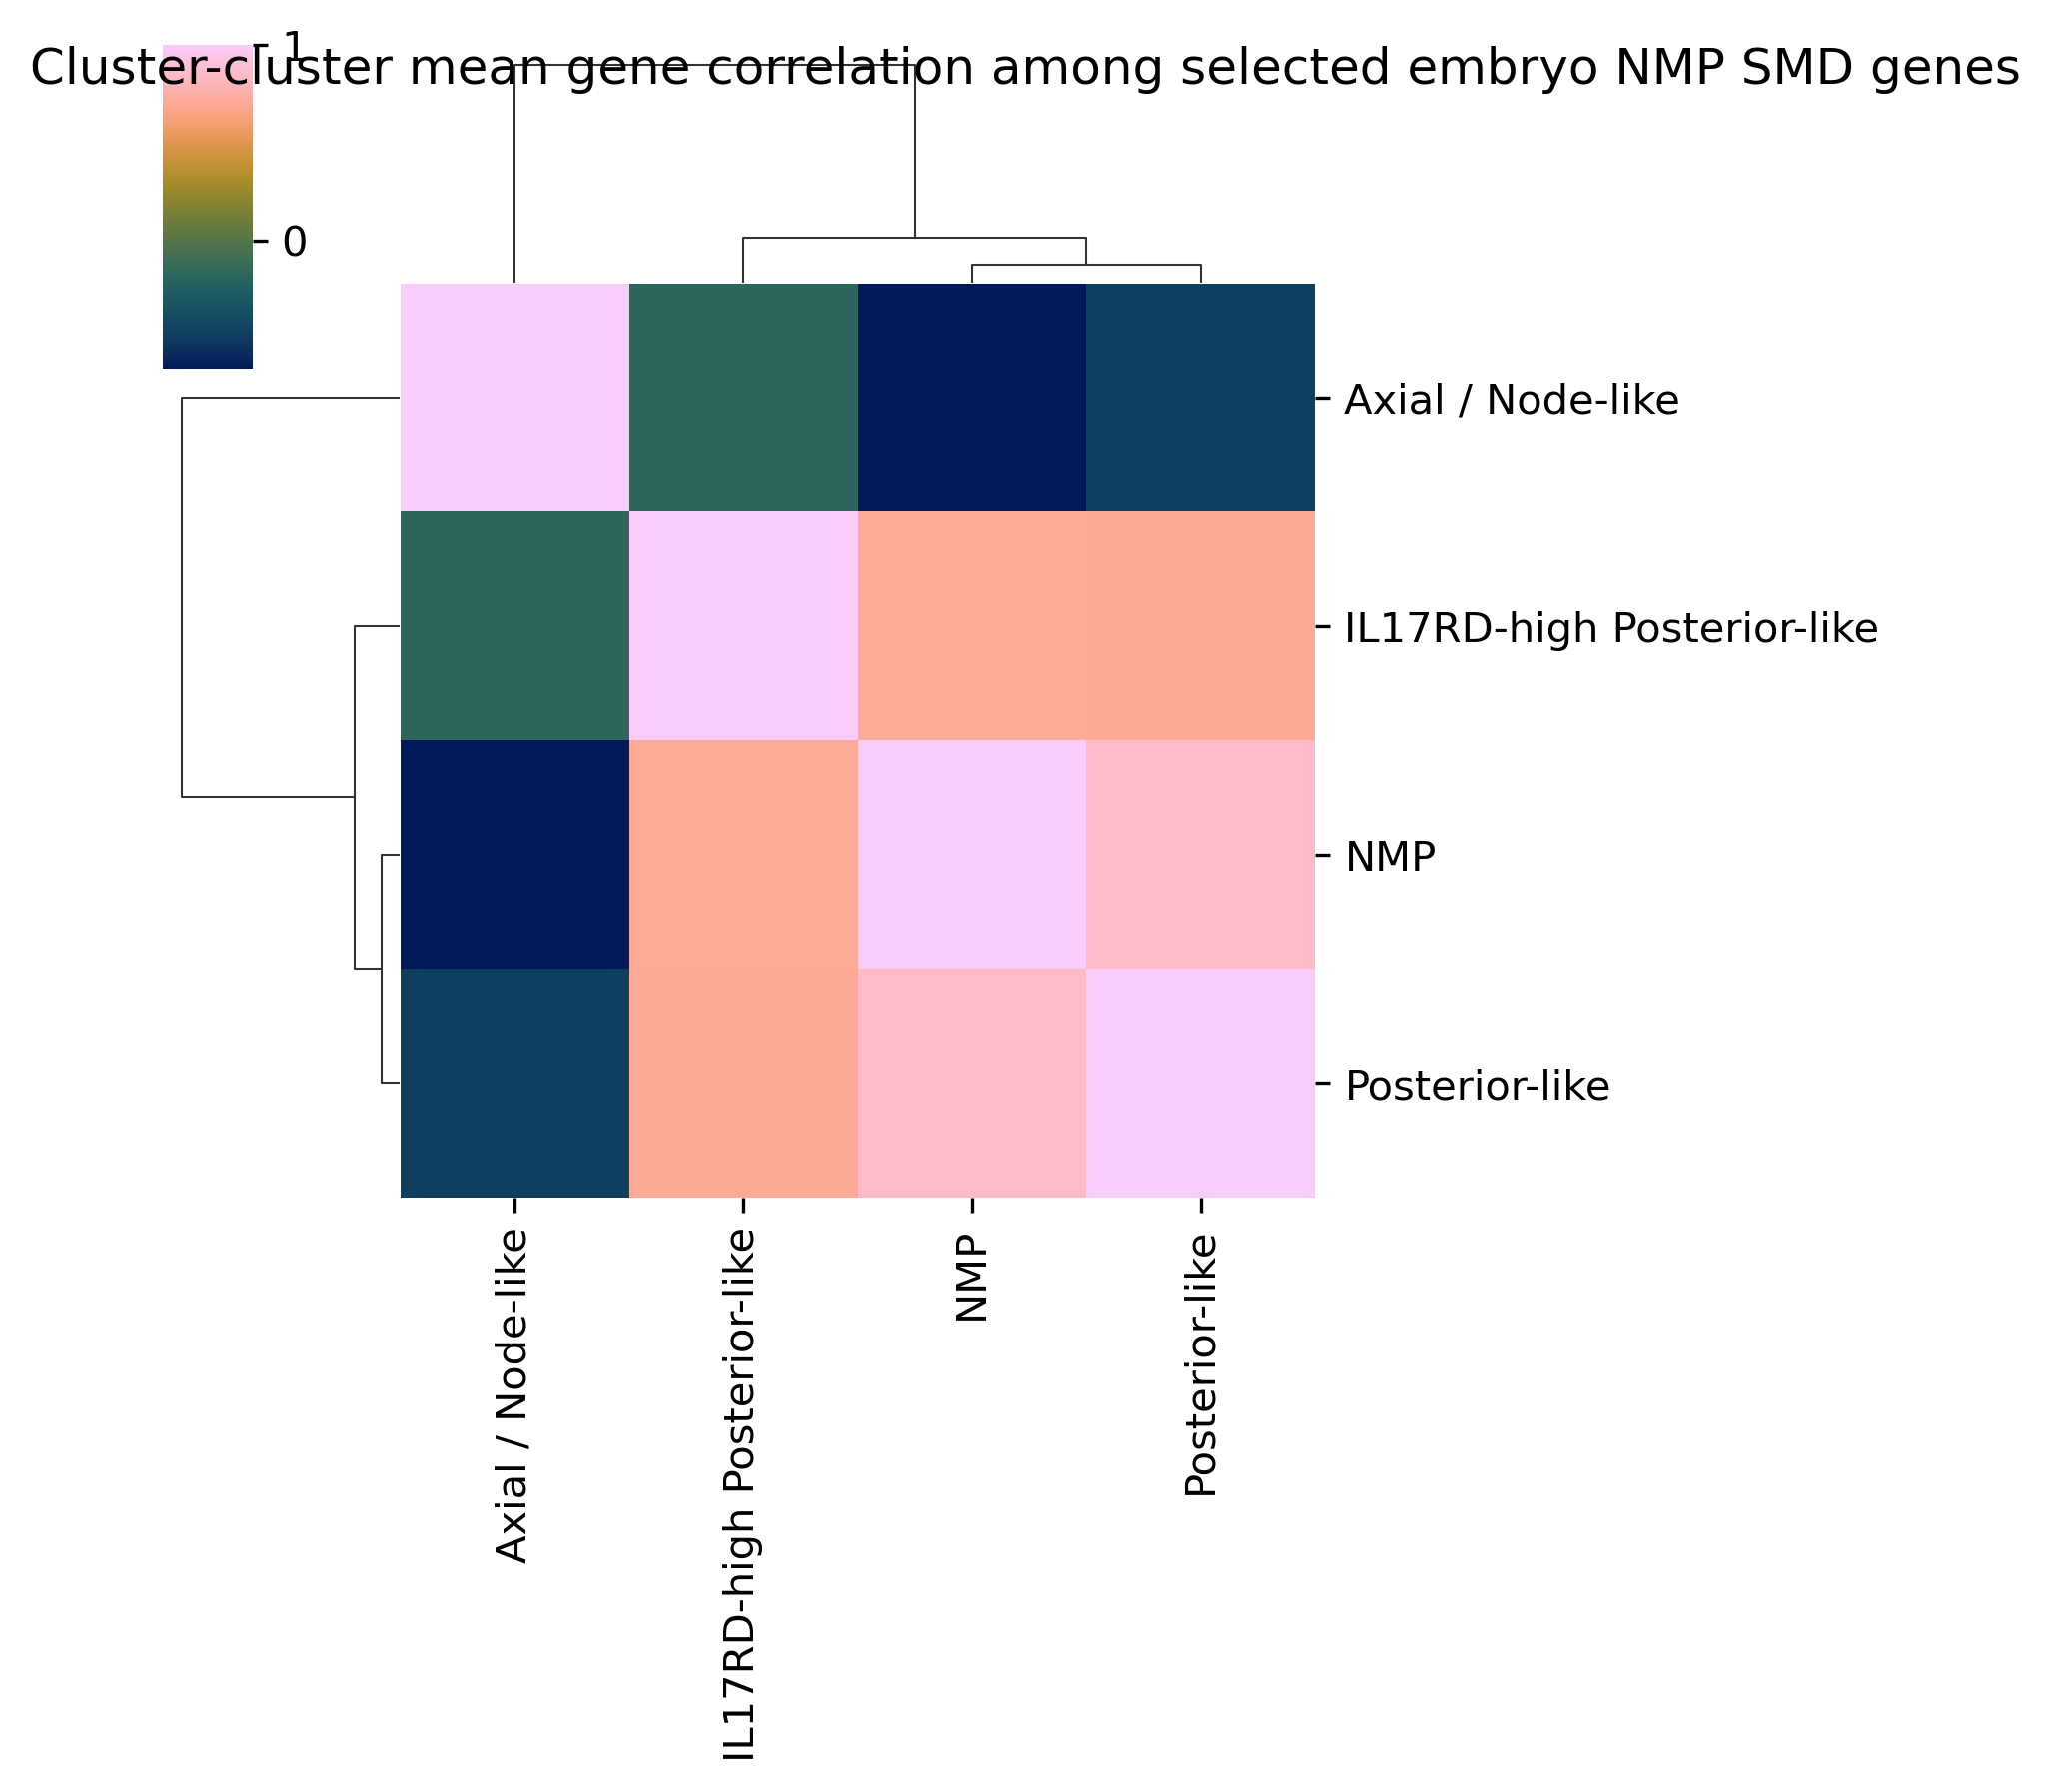

In [ ]:

adata_embryo_nmp_SMD_leiden = sc.get.aggregate(
    adata_embryo_nmp_SMD_,
    by="leiden_embryo_nmp",
    func=["count_nonzero", "mean", "sum", "var"],
    axis="obs",
)

corr_clcl_embryo_nmp = np.corrcoef(adata_embryo_nmp_SMD_leiden.layers["mean"])
with plt.rc_context({"figure.figsize": (6, 5), "figure.dpi": 300}):
    cluster_clcl_embryo_nmp = sns.clustermap(
        corr_clcl_embryo_nmp,
        method="ward",
        metric="euclidean",
        figsize=(6, 6),
        cmap=batlow,
        yticklabels=adata_embryo_nmp_SMD_leiden.obs.leiden_embryo_nmp.cat.categories,
        xticklabels=adata_embryo_nmp_SMD_leiden.obs.leiden_embryo_nmp.cat.categories,
    )
    cluster_clcl_embryo_nmp.fig.suptitle(
        "Cluster-cluster mean gene correlation among selected embryo NMP SMD genes"
    )
    cluster_clcl_embryo_nmp.savefig(fig_path / "nmp_cluster_cluster_correlation.png", dpi=300)
    cluster_clcl_embryo_nmp.savefig(fig_path / "nmp_cluster_cluster_correlation.pdf")
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


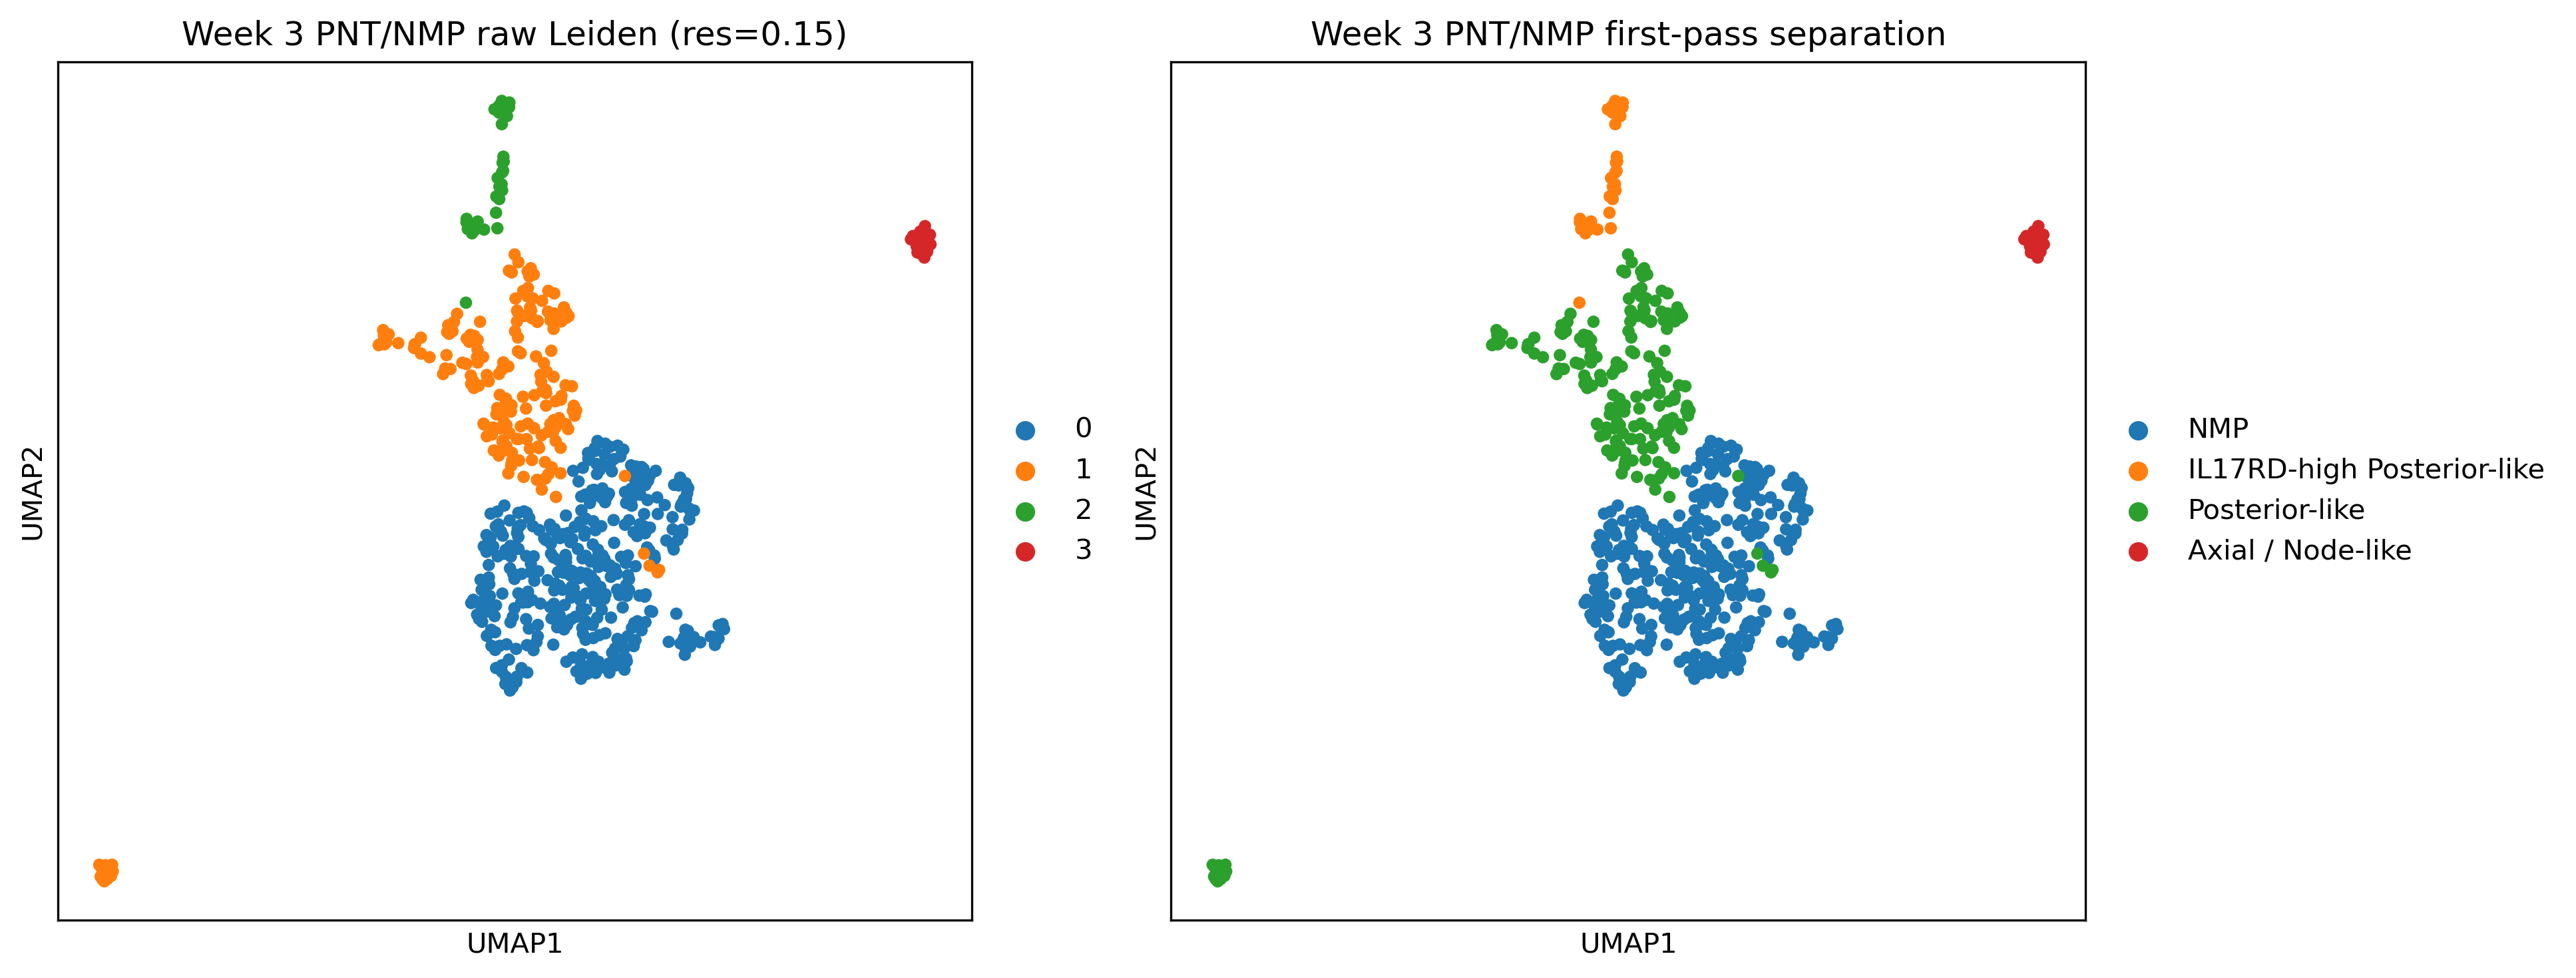

In [ ]:

adata_embryo_nmp_SMD_ = adata_embryo_nmp_SMD_[
    adata_embryo_nmp_SMD_.obs.sort_values(["leiden_embryo_nmp", "leiden_embryo_nmp_raw"]).index, :
]
adata_embryo_nmp_with_clusters = adata_embryo_nmp_with_clusters[
    adata_embryo_nmp_with_clusters.obs.sort_values(["leiden_embryo_nmp", "leiden_embryo_nmp_raw"]).index, :
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)
sc.pl.umap(
    adata_embryo_nmp_SMD_,
    color="leiden_embryo_nmp_raw",
    title=f"Week 3 PNT/NMP raw Leiden (res={CHOSEN_LEIDEN_RESOLUTION:.2f})",
    size=80,
    show=False,
    ax=axes[0],
)
sc.pl.umap(
    adata_embryo_nmp_SMD_,
    color="leiden_embryo_nmp",
    title="Week 3 PNT/NMP first-pass separation",
    size=80,
    show=False,
    ax=axes[1],
)
fig.tight_layout()
fig.savefig(fig_path / "nmp_umap.png", dpi=300, bbox_inches="tight")
fig.savefig(fig_path / "nmp_umap.pdf", bbox_inches="tight")
plt.show()


## Calculate NMP DEGs by Multinomial Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg_cluster_order = list(adata_embryo_nmp_with_clusters.obs["leiden_embryo_nmp"].cat.categories)
X_logreg = adata_embryo_nmp_with_clusters.X
if scipy.sparse.issparse(X_logreg):
    X_logreg = X_logreg.tocsr()
y_codes = adata_embryo_nmp_with_clusters.obs["leiden_embryo_nmp"].cat.codes.to_numpy()

clf = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    solver="lbfgs",
    random_state=0,
)
clf.fit(X_logreg, y_codes)

deg_name_map = {}
deg_score_map = {}
deg_direction_map = {}

if clf.coef_.shape[0] == 1 and len(logreg_cluster_order) == 2:
    # Make the binary case explicit: top positive coefficients define classes_[1],
    # and top negative coefficients define classes_[0].
    coef_vector = clf.coef_[0]
    positive_code = int(clf.classes_[1])
    negative_code = int(clf.classes_[0])
    positive_cluster = logreg_cluster_order[positive_code]
    negative_cluster = logreg_cluster_order[negative_code]

    positive_ranked_idx = np.argsort(coef_vector)[::-1][:100]
    negative_ranked_idx = np.argsort(coef_vector)[:100]

    deg_name_map[positive_cluster] = adata_embryo_nmp_with_clusters.var_names[positive_ranked_idx].tolist()
    deg_score_map[positive_cluster] = coef_vector[positive_ranked_idx].astype(float).tolist()
    deg_direction_map[positive_cluster] = ["positive"] * len(positive_ranked_idx)

    deg_name_map[negative_cluster] = adata_embryo_nmp_with_clusters.var_names[negative_ranked_idx].tolist()
    deg_score_map[negative_cluster] = coef_vector[negative_ranked_idx].astype(float).tolist()
    deg_direction_map[negative_cluster] = ["negative"] * len(negative_ranked_idx)
else:
    for row_idx, class_code in enumerate(clf.classes_):
        cluster_name = logreg_cluster_order[int(class_code)]
        coef_vector = clf.coef_[row_idx]
        ranked_idx = np.argsort(coef_vector)[::-1][:100]
        deg_name_map[cluster_name] = adata_embryo_nmp_with_clusters.var_names[ranked_idx].tolist()
        deg_score_map[cluster_name] = coef_vector[ranked_idx].astype(float).tolist()
        deg_direction_map[cluster_name] = ["positive"] * len(ranked_idx)

DEGs_embryo_multi_nmp = pd.DataFrame(deg_name_map)
DEGscores_embryo_multi_nmp = pd.DataFrame(deg_score_map)
DEGdirections_embryo_multi_nmp = pd.DataFrame(deg_direction_map)
DEGs_embryo_multi_nmp.to_csv(table_path / "nmp_top100_logreg_deg_names.csv", index=False)
DEGscores_embryo_multi_nmp.to_csv(table_path / "nmp_top100_logreg_deg_scores.csv", index=False)
DEGdirections_embryo_multi_nmp.to_csv(table_path / "nmp_top100_logreg_deg_directions.csv", index=False)

deg_long_rows = []
for cluster_name in DEGs_embryo_multi_nmp.columns:
    for rank, (gene_id, score, direction) in enumerate(
        zip(
            DEGs_embryo_multi_nmp[cluster_name],
            DEGscores_embryo_multi_nmp[cluster_name],
            DEGdirections_embryo_multi_nmp[cluster_name],
        ),
        start=1,
    ):
        deg_long_rows.append(
            {
                "cluster": cluster_name,
                "rank": rank,
                "gene_id": gene_id,
                "gene_symbol": str(adata_embryo_nmp_with_clusters.var.loc[gene_id, "gene_symbol"]),
                "score": float(score),
                "direction": str(direction),
            }
        )
deg_long_df = pd.DataFrame(deg_long_rows)
deg_long_df.to_csv(table_path / "nmp_top100_logreg_deg_long.csv", index=False)

deg_long_df.head(20)

   cluster  rank          gene_id gene_symbol     score direction
0      NMP     1  ENSG00000164458        TBXT  0.073614  positive
1      NMP     2  ENSG00000137198        GMPR  0.072177  positive
2      NMP     3  ENSG00000158815       FGF17  0.045872  positive
3      NMP     4  ENSG00000117906        RCN2  0.039017  positive
4      NMP     5  ENSG00000140416        TPM1  0.035931  positive
5      NMP     6  ENSG00000111186       WNT5B  0.035811  positive
6      NMP     7  ENSG00000198729    PPP1R14C  0.034715  positive
7      NMP     8  ENSG00000179111        HES7  0.034291  positive
8      NMP     9  ENSG00000125968         ID1  0.032139  positive
9      NMP    10  ENSG00000140545       MFGE8  0.029565  positive
10     NMP    11  ENSG00000147257        GPC3  0.029043  positive
11     NMP    12  ENSG00000095596     CYP26A1  0.028395  positive
12     NMP    13  ENSG00000117318         ID3  0.027515  positive
13     NMP    14  ENSG00000137563         GGH  0.026523  positive
14     NMP

## Selected NMP SMD Gene Heatmap

/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


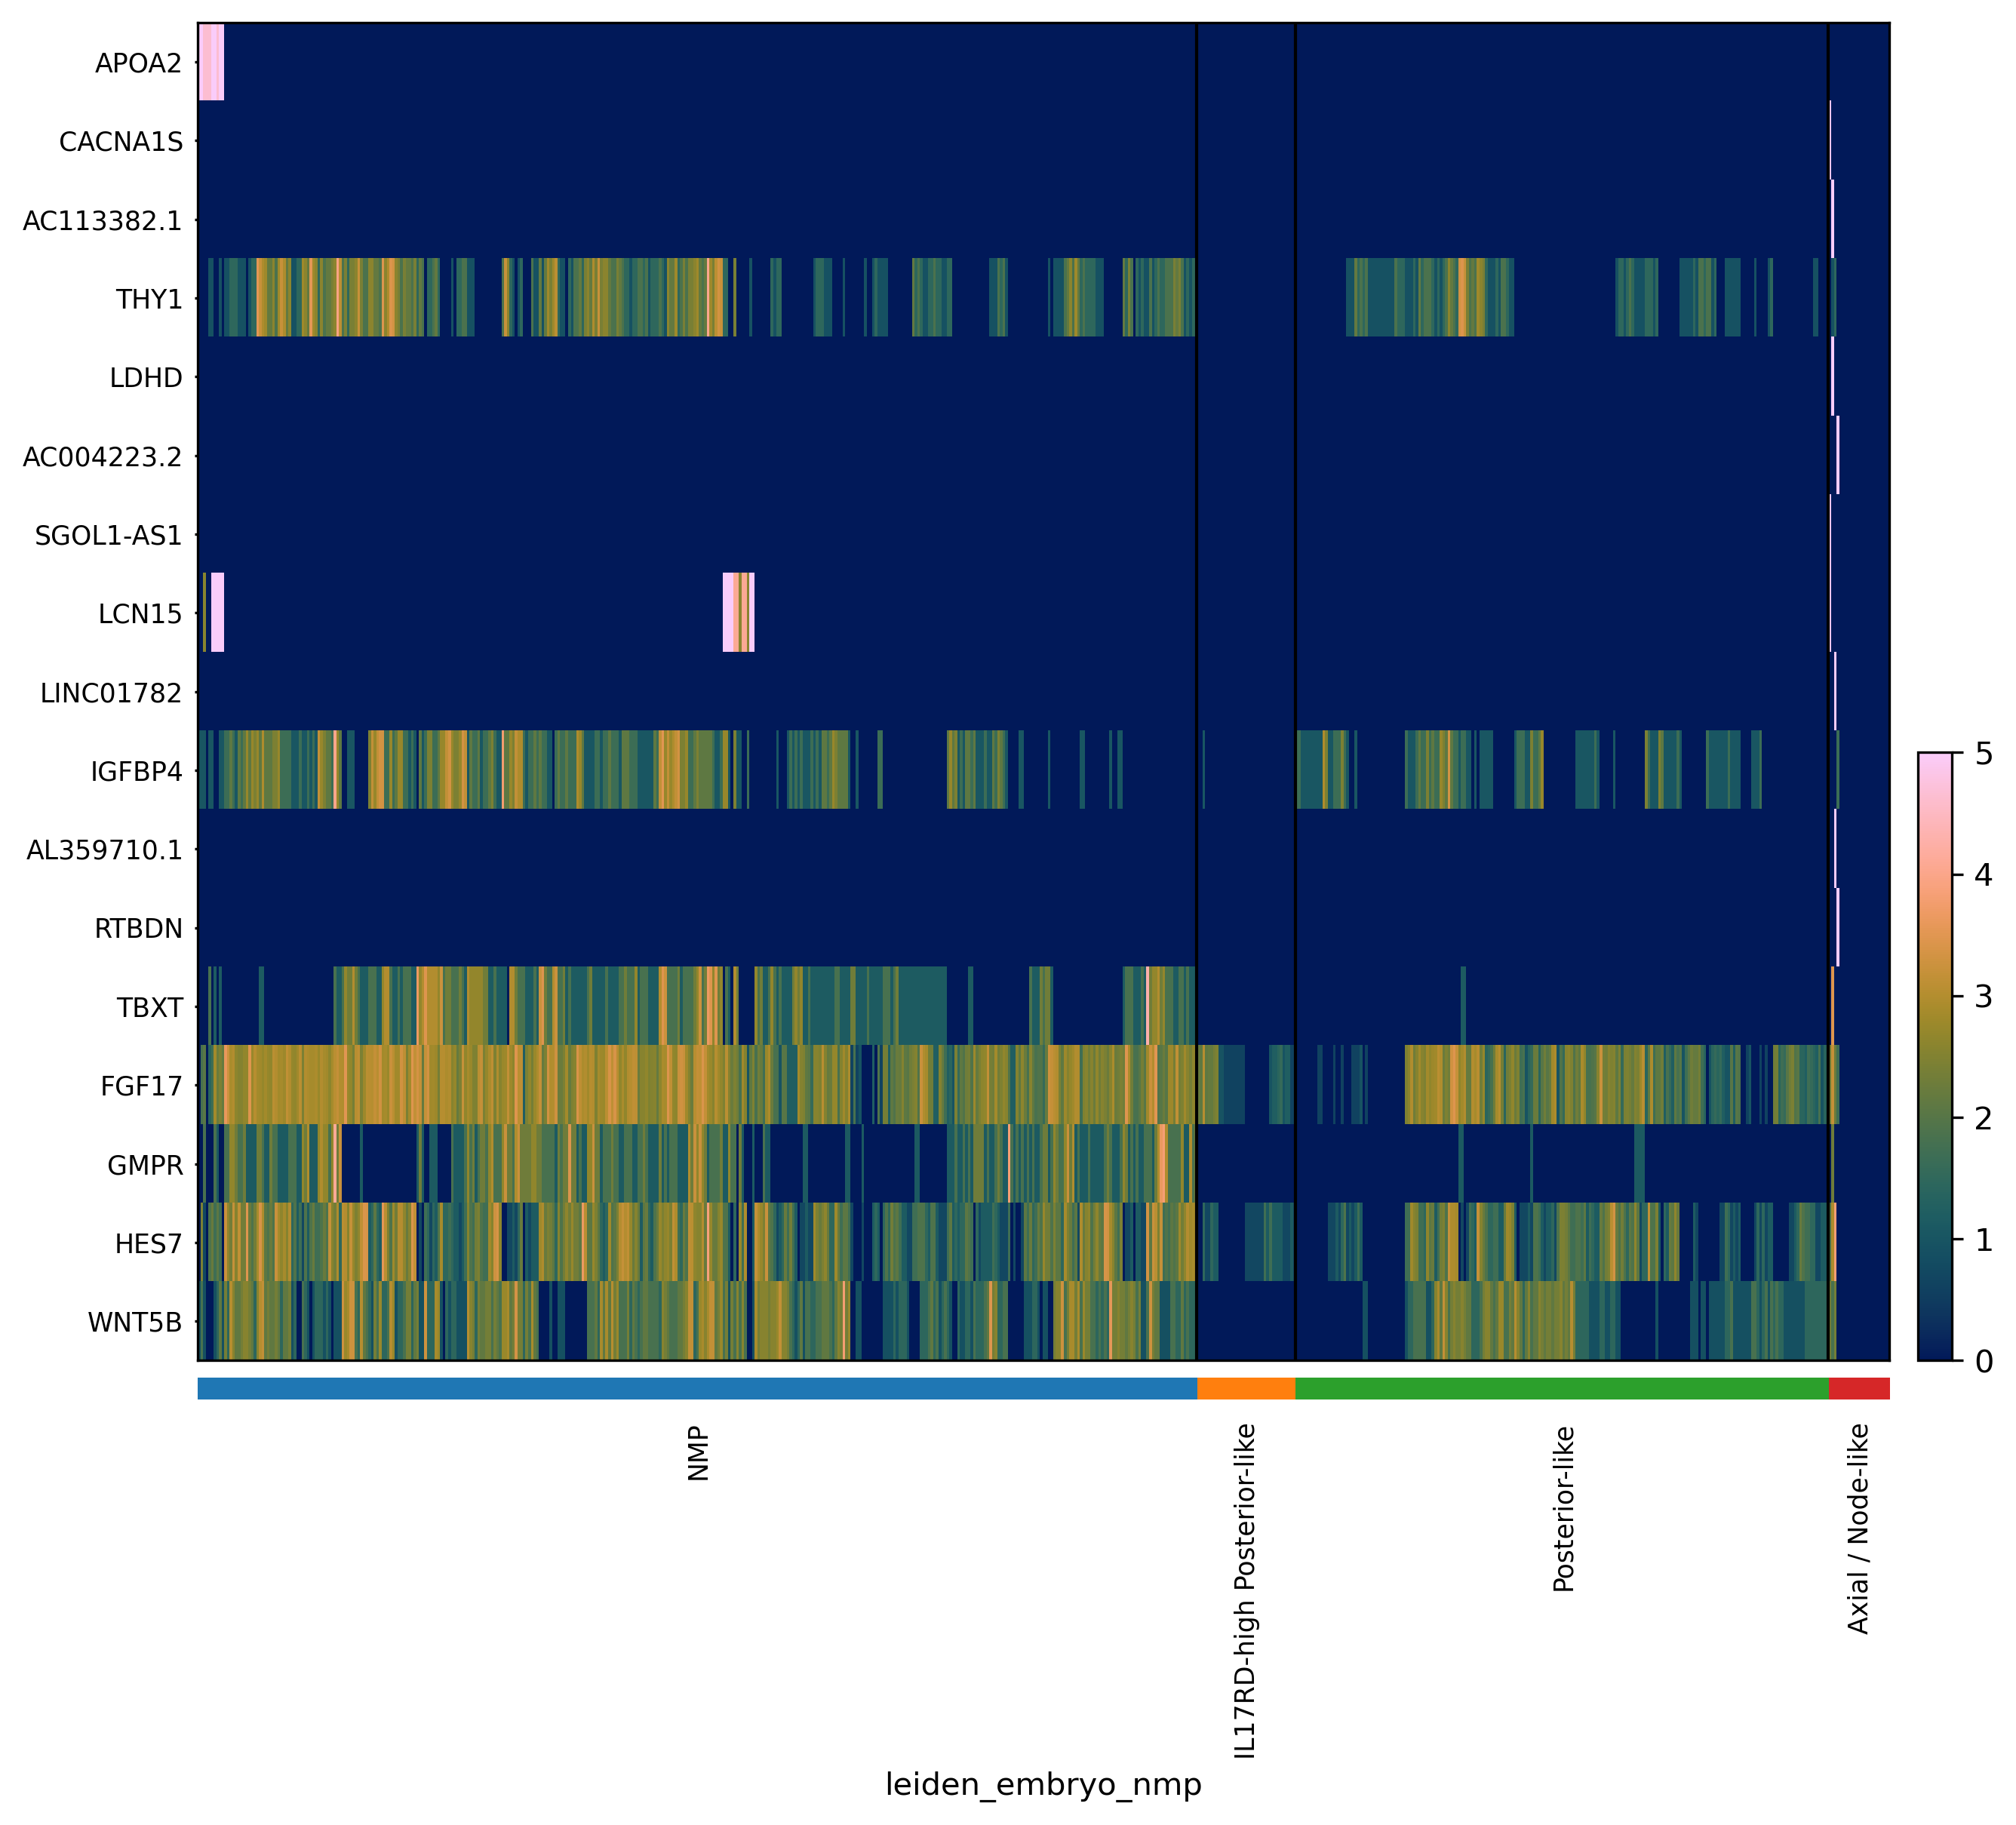

In [ ]:
smd_heatmap_gene_ids = list(adata_embryo_nmp_SMD.var_names)
smd_heatmap_order = ordered_cells_by_cluster_clustermap(
    adata=adata_embryo_nmp_with_clusters[:, smd_heatmap_gene_ids].copy(),
    cluster_key="leiden_embryo_nmp",
    var_names=smd_heatmap_gene_ids,
    figsize=(8, 8),
    vmin=0,
    vmax=5,
    cmap=batlow,
    method="ward",
    metric="euclidean",
)
pd.DataFrame(
    {
        "cell_id": smd_heatmap_order,
        "leiden_embryo_nmp": adata_embryo_nmp_with_clusters.obs.loc[smd_heatmap_order, "leiden_embryo_nmp"].astype(str).values,
    }
).to_csv(table_path / "nmp_selected_smd_gene_heatmap_cell_order.csv", index=False)

adata_embryo_nmp_smd_heatmap = adata_embryo_nmp_with_clusters[smd_heatmap_order, smd_heatmap_gene_ids].copy()

with plt.rc_context({"figure.dpi": 300}):
    sc.pl.heatmap(
        adata_embryo_nmp_smd_heatmap,
        var_names=smd_heatmap_gene_ids,
        groupby="leiden_embryo_nmp",
        swap_axes=True,
        show_gene_labels=True,
        figsize=(10, 8),
        cmap=batlow,
        vmin=0,
        vmax=5,
        dendrogram=False,
        show=False,
    )
    plt.savefig(fig_path / "nmp_selected_smd_gene_heatmap.png", dpi=300, bbox_inches="tight")
    plt.savefig(fig_path / "nmp_selected_smd_gene_heatmap.pdf", bbox_inches="tight")
    plt.show()


## NMP DEG Heatmap with Intracluster Cell Ordering

/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


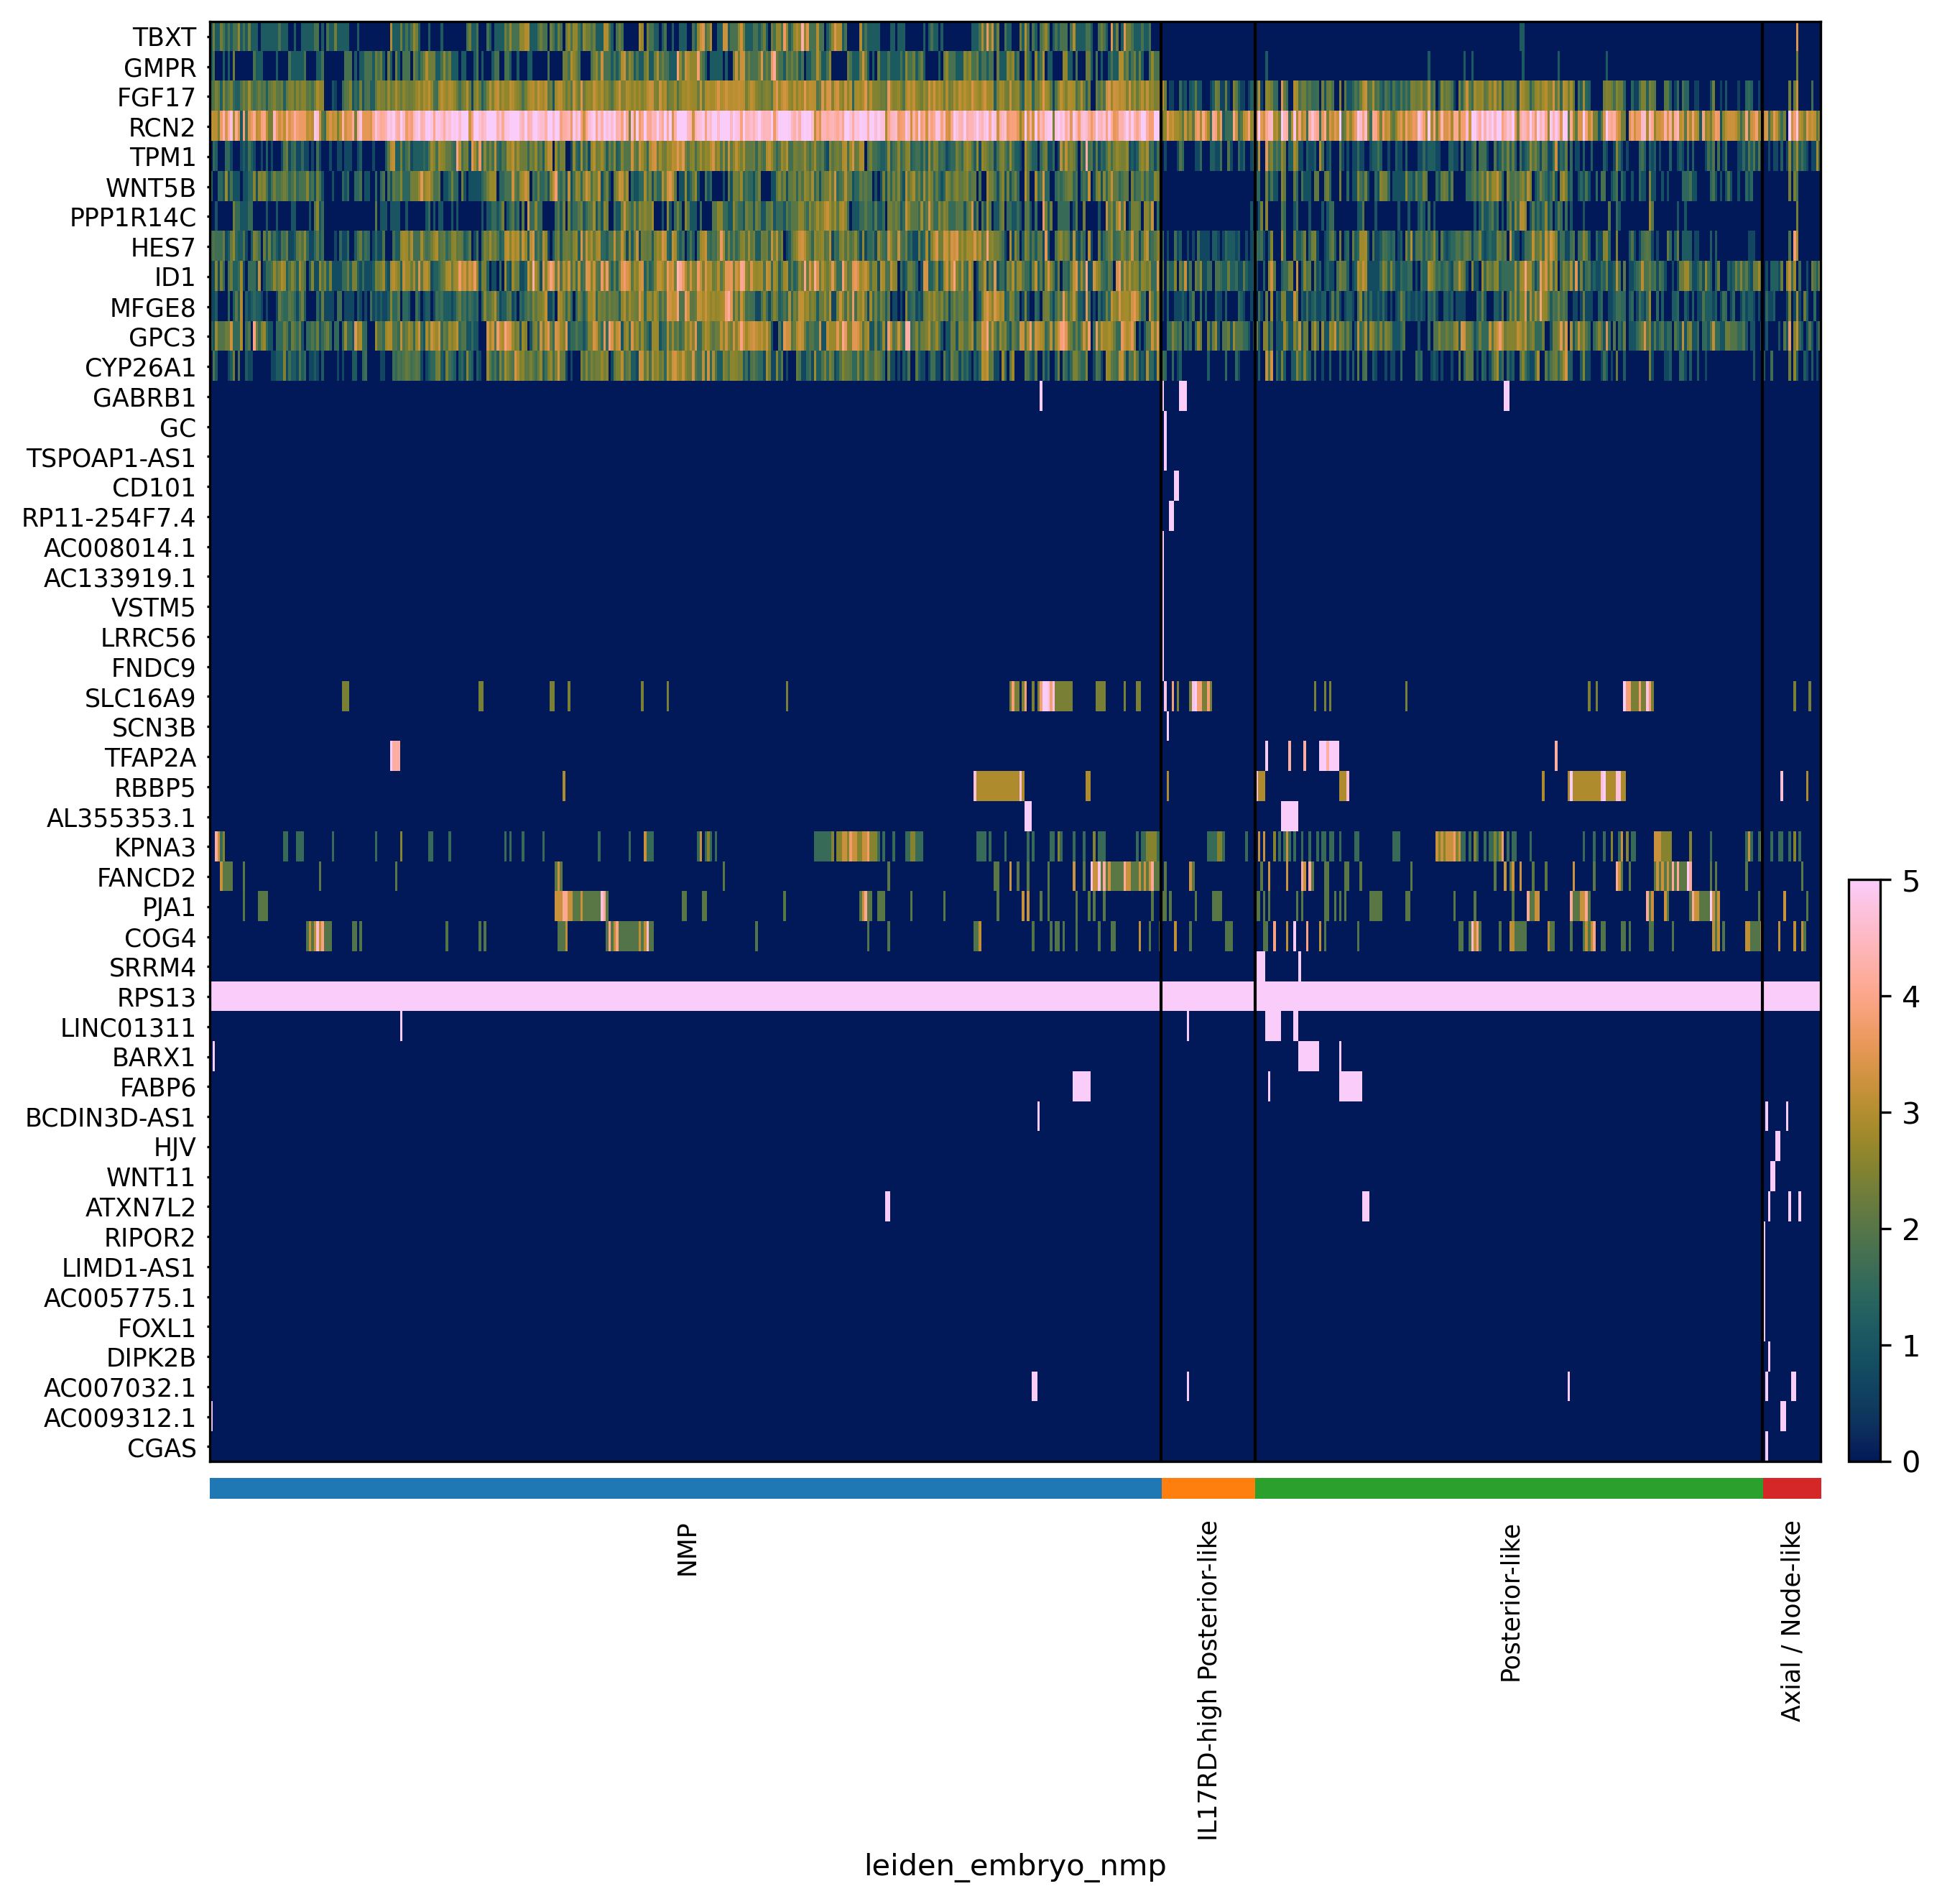

In [ ]:
top_deg_per_cluster_for_heatmap = 12
heatmap_gene_ids = []
heatmap_cluster_order = [
    cluster_name
    for cluster_name in adata_embryo_nmp_with_clusters.obs["leiden_embryo_nmp"].cat.categories
    if cluster_name in DEGs_embryo_multi_nmp.columns
]
for cluster_name in heatmap_cluster_order:
    cluster_gene_ids = DEGs_embryo_multi_nmp[cluster_name].tolist()[:top_deg_per_cluster_for_heatmap]
    for gene_id in cluster_gene_ids:
        if gene_id not in heatmap_gene_ids:
            heatmap_gene_ids.append(gene_id)

pd.DataFrame(
    {
        "cluster": np.repeat(heatmap_cluster_order, top_deg_per_cluster_for_heatmap),
        "rank": np.tile(np.arange(1, top_deg_per_cluster_for_heatmap + 1), len(heatmap_cluster_order)),
        "gene_id": [gene_id for cluster_name in heatmap_cluster_order for gene_id in DEGs_embryo_multi_nmp[cluster_name].tolist()[:top_deg_per_cluster_for_heatmap]],
        "gene_symbol": [str(adata_embryo_nmp_with_clusters.var.loc[gene_id, "gene_symbol"]) for cluster_name in heatmap_cluster_order for gene_id in DEGs_embryo_multi_nmp[cluster_name].tolist()[:top_deg_per_cluster_for_heatmap]],
        "score": [float(score) for cluster_name in heatmap_cluster_order for score in DEGscores_embryo_multi_nmp[cluster_name].tolist()[:top_deg_per_cluster_for_heatmap]],
        "direction": [str(direction) for cluster_name in heatmap_cluster_order for direction in DEGdirections_embryo_multi_nmp[cluster_name].tolist()[:top_deg_per_cluster_for_heatmap]],
    }
).to_csv(table_path / "nmp_deg_heatmap_gene_list.csv", index=False)

adata_embryo_nmp_heatmap = adata_embryo_nmp_with_clusters[:, heatmap_gene_ids].copy()
heatmap_cell_order = ordered_cells_by_cluster_clustermap(
    adata=adata_embryo_nmp_heatmap,
    cluster_key="leiden_embryo_nmp",
    var_names=adata_embryo_nmp_heatmap.var_names,
    figsize=(8, 8),
    vmin=0,
    vmax=5,
    cmap=batlow,
    method="ward",
    metric="euclidean",
)
pd.DataFrame(
    {
        "cell_id": heatmap_cell_order,
        "leiden_embryo_nmp": adata_embryo_nmp_with_clusters.obs.loc[heatmap_cell_order, "leiden_embryo_nmp"].astype(str).values,
    }
).to_csv(table_path / "nmp_heatmap_cell_order.csv", index=False)

adata_embryo_nmp_heatmap = adata_embryo_nmp_heatmap[heatmap_cell_order, heatmap_gene_ids].copy()

with plt.rc_context({"figure.dpi": 300}):
    sc.pl.heatmap(
        adata_embryo_nmp_heatmap,
        var_names=heatmap_gene_ids,
        groupby="leiden_embryo_nmp",
        swap_axes=True,
        show_gene_labels=True,
        figsize=(10, 9),
        cmap=batlow,
        vmin=0,
        vmax=5,
        dendrogram=False,
        show=False,
    )
    plt.savefig(fig_path / "nmp_logreg_deg_heatmap.png", dpi=300, bbox_inches="tight")
    plt.savefig(fig_path / "nmp_logreg_deg_heatmap.pdf", bbox_inches="tight")
    plt.show()

## Save Stage Outputs

In [ ]:
save_npz(stage_path / "embryo_nmp_07c.npz", adata_embryo_nmp_filtered.X)
save_h5ad(adata_embryo_nmp_filtered, stage_path / "adata_embryo_nmp_filtered.h5ad")
save_h5ad(adata_embryo_nmp_, stage_path / "adata_embryo_nmp_.h5ad")
save_h5ad(adata_embryo_nmp_SMD, stage_path / "adata_embryo_nmp_SMD.h5ad")
save_h5ad(adata_embryo_nmp_SMD_, stage_path / "adata_embryo_nmp_SMD_.h5ad")
save_h5ad(adata_embryo_nmp_with_clusters, stage_path / "adata_embryo_nmp_with_clusters.h5ad")

adata_embryo_nmp_with_clusters.obs[["leiden_embryo", "leiden_embryo_nmp", "leiden_embryo_nmp_raw"]].to_csv(
    table_path / "nmp_cluster_labels.csv"
)

save_json(
    {
        "stage": STAGE_ID,
        "seed_policy": "all seeds set to 0",
        "upstream_stage": "07_human_embryo",
        "upstream_identification_stage": "07c_human_embryo_nmp_identification",
        "parent_clusters": nmp_parent_clusters,
        "preferred_fresh_smd_substrate": "embryo_nmp",
        "n_parent_cluster_cells": int(adata_embryo_nmp_.n_obs),
        "n_pre_smd_genes": int(adata_embryo_nmp_filtered.n_vars),
        "n_postfilter_genes": int(adata_embryo_nmp_.n_vars),
        "recommended_n_sub": int(0.8 * adata_embryo_nmp_filtered.n_obs),
        "smd_input_matrix": "embryo_nmp_07c.npz",
        "filtered_artifact": "adata_embryo_nmp_filtered.h5ad",
        "downstream_artifact": "adata_embryo_nmp_.h5ad",
        "smd_artifact": "adata_embryo_nmp_SMD.h5ad",
        "smd_cluster_artifact": "adata_embryo_nmp_with_clusters.h5ad",
        "smd_z_score_file": z_score_file.name,
        "smd_cutoff": smd_cutoff,
        "manual_addgenes": manual_addgenes,
        "n_selected_smd_genes": int(adata_embryo_nmp_SMD.n_vars),
        "resolution_scan_values": scan_resolutions,
        "neighbor_graph_method": "scanpy default neighbors on selected embryo NMP SMD genes",
        "chosen_leiden_resolution": CHOSEN_LEIDEN_RESOLUTION,
        "chosen_leiden_reason": CHOSEN_LEIDEN_REASON,
        "raw_cluster_key": "leiden_embryo_nmp_raw",
        "raw_cluster_labels": list(adata_embryo_nmp_with_clusters.obs["leiden_embryo_nmp_raw"].cat.categories),
        "cluster_key": "leiden_embryo_nmp",
        "cluster_labels": list(adata_embryo_nmp_with_clusters.obs["leiden_embryo_nmp"].cat.categories),
        "cluster_name_map": cluster_name_map,
        "nmp_raw_cluster": nmp_raw_cluster,
        "il17rd_high_raw_cluster": il17rd_high_raw_cluster,
        "posterior_neural_raw_cluster": posterior_neural_raw_cluster,
        "axial_raw_cluster": axial_raw_cluster,
        "tables_dir": "tables",
        "figures_dir": "figures",
    },
    stage_path / "meta.json",
)

print(f"Saved NMP clustering outputs to {stage_path}")


Saved NMP clustering outputs to <analysis-root>/parity/results/intermediates/07c_human_embryo_nmp_subclustering
